<a href="https://colab.research.google.com/github/ssssssshy/project/blob/main/Workout%20%26%20Fitness%20Tracker%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [90]:
df = pd.read_csv('workout_fitness_tracker_data.csv')

In [91]:
df.head()

,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout
0,1,39,Male,175,99,Cycling,79,384,112,8850,14.44,High,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued
1,2,36,Other,157,112,Cardio,73,612,168,2821,1.10,High,8.6,1.9,2541,73,38.4,28.5,Happy,Energized
2,3,25,Female,180,66,HIIT,27,540,133,18898,7.28,High,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued
3,4,56,Male,154,89,Cycling,39,672,118,14102,6.55,Medium,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral
4,5,53,Other,194,59,Strength,56,410,170,16518,3.17,Medium,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized


User ID – Уникальный идентификатор каждого пользователя.

Age – Возраст пользователя (от 18 до 60 лет).

Gender – Пол пользователя (Мужской, Женский, Другой).

Height (cm) – Рост пользователя в сантиметрах.

Weight (kg) – Вес пользователя в килограммах.

Workout Type – Тип тренировки (Кардио, Силовая, Йога, HIIT, Велосипед, Бег).

Workout Duration (mins) – Общее время, затраченное на тренировку (в минутах).

Calories Burned – Общее количество сожженных калорий во время тренировки.

Heart Rate (bpm) – Средний пульс во время тренировки (ударов в минуту).

Steps Taken – Количество шагов (для тренировок, связанных с ходьбой/бегом).

Distance (km) – Пройденное расстояние в километрах.

Workout Intensity – Интенсивность тренировки (Низкая, Средняя, Высокая).

Sleep Hours – Количество часов сна перед тренировкой.

Water Intake (liters) – Количество выпитой воды в литрах.

Daily Calories Intake – Общее количество потребленных калорий за день.

Resting Heart Rate (bpm) – Пульс в состоянии покоя (ударов в минуту).

VO2 Max – Максимальное потребление кислорода (показатель кардиореспираторной выносливости).

Body Fat (%) – Процентное содержание жира в организме.

Mood Before Workout – Настроение перед тренировкой (Радостное, Нейтральное, Усталость, Стресс).

Mood After Workout – Настроение после тренировки (Прилив энергии, Нейтральное, Усталость)




In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User ID                   10000 non-null  int64  
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  object 
 3   Height (cm)               10000 non-null  int64  
 4   Weight (kg)               10000 non-null  int64  
 5   Workout Type              10000 non-null  object 
 6   Workout Duration (mins)   10000 non-null  int64  
 7   Calories Burned           10000 non-null  int64  
 8   Heart Rate (bpm)          10000 non-null  int64  
 9   Steps Taken               10000 non-null  int64  
 10  Distance (km)             10000 non-null  float64
 11  Workout Intensity         10000 non-null  object 
 12  Sleep Hours               10000 non-null  float64
 13  Water Intake (liters)     10000 non-null  float64
 14  Daily C

In [93]:
df.describe()

,User ID,Age,Height (cm),Weight (kg),Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%)
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,1.000000e+04,10000.0
mean,5000.50000,38.390100,174.275100,84.903000,64.464800,552.100800,129.526700,10455.496600,7.820745,6.982820,1.900000e+00,2748.428800,69.486500,3.840000e+01,28.5
std,2886.89568,12.171637,14.440986,20.189937,31.814946,260.629908,28.874152,5486.423716,4.159148,1.708738,2.109529e-14,717.109026,11.566763,4.590336e-12,0.0
min,1.00000,18.000000,150.000000,50.000000,10.000000,100.000000,80.000000,1000.000000,0.500000,4.000000,1.900000e+00,1500.000000,50.000000,3.840000e+01,28.5
25%,2500.75000,28.000000,162.000000,67.000000,37.000000,325.000000,105.000000,5673.000000,4.240000,5.500000,1.900000e+00,2124.000000,60.000000,3.840000e+01,28.5
50%,5000.50000,38.000000,174.000000,85.000000,64.000000,554.000000,130.000000,10434.500000,7.850000,7.000000,1.900000e+00,2753.000000,69.000000,3.840000e+01,28.5
75%,7500.25000,49.000000,187.000000,102.000000,92.000000,776.000000,155.000000,15211.000000,11.410000,8.400000,1.900000e+00,3360.000000,80.000000,3.840000e+01,28.5
max,10000.00000,59.000000,199.000000,119.000000,119.000000,999.000000,179.000000,19998.000000,15.000000,10.000000,1.900000e+00,3999.000000,89.000000,3.840000e+01,28.5


In [94]:
df.isnull().sum()

,0
User ID,0
Age,0
Gender,0
Height (cm),0
Weight (kg),0
Workout Type,0
Workout Duration (mins),0
Calories Burned,0
Heart Rate (bpm),0
Steps Taken,0


In [95]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


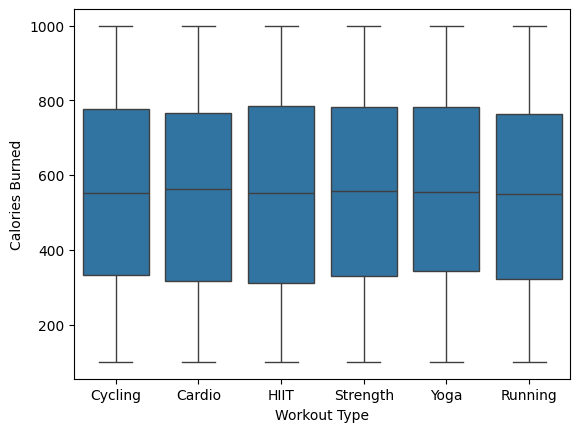

In [96]:
sns.boxplot(x='Workout Type', y='Calories Burned', data=df)
plt.show()

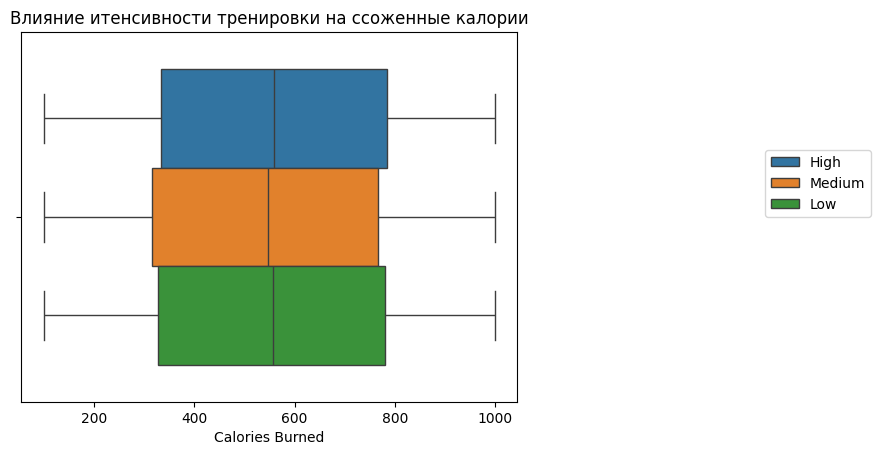

In [97]:
sns.boxplot(data=df, x = 'Calories Burned',hue = 'Workout Intensity')
plt.title('Влияние итенсивности тренировки на ссоженные калории');
plt.legend(loc = (1.5,0.5))

Анализ влияния сна на эффективность тренировок

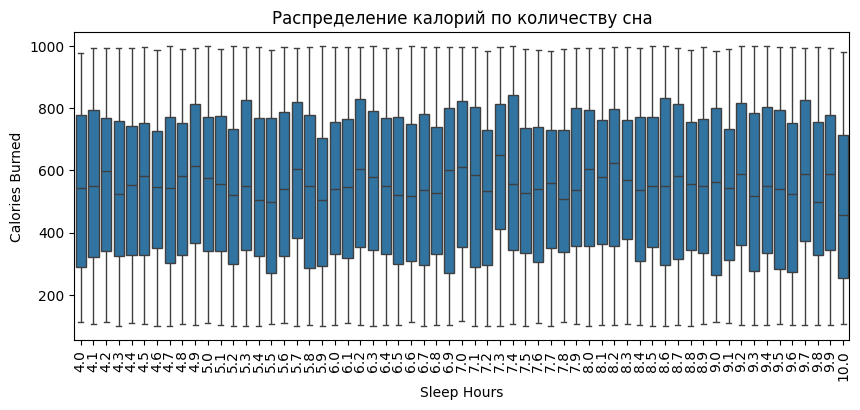

In [98]:
plt.figure(figsize = (10,4))
sns.boxplot(x='Sleep Hours', y='Calories Burned', data=df)
plt.title('Распределение калорий по количеству сна')
plt.xticks(rotation = 90);

Text(0.5, 1.0, 'Тренд влияния сна на калории')

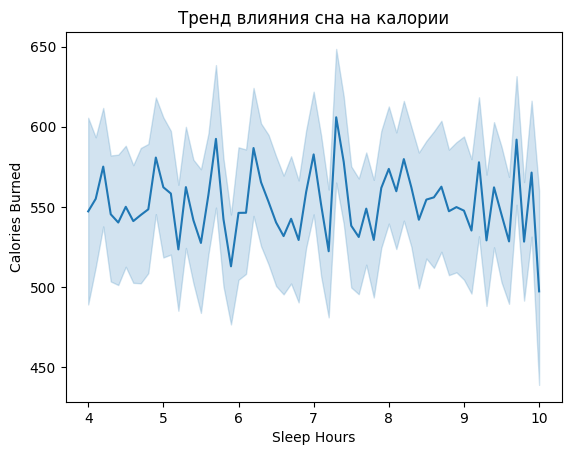

In [99]:
sns.lineplot(x='Sleep Hours', y='Calories Burned', data=df)
plt.title('Тренд влияния сна на калории')

Анализ влияния питания на результаты тренировок

In [100]:
df['Water Intake (liters)'].value_counts()

,count
Water Intake (liters),
1.9,10000


In [101]:
df.head()

,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout
0,1,39,Male,175,99,Cycling,79,384,112,8850,14.44,High,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued
1,2,36,Other,157,112,Cardio,73,612,168,2821,1.10,High,8.6,1.9,2541,73,38.4,28.5,Happy,Energized
2,3,25,Female,180,66,HIIT,27,540,133,18898,7.28,High,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued
3,4,56,Male,154,89,Cycling,39,672,118,14102,6.55,Medium,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral
4,5,53,Other,194,59,Strength,56,410,170,16518,3.17,Medium,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized


Text(0.5, 1.0, 'Тепловая карта корреляции числовых признаков')

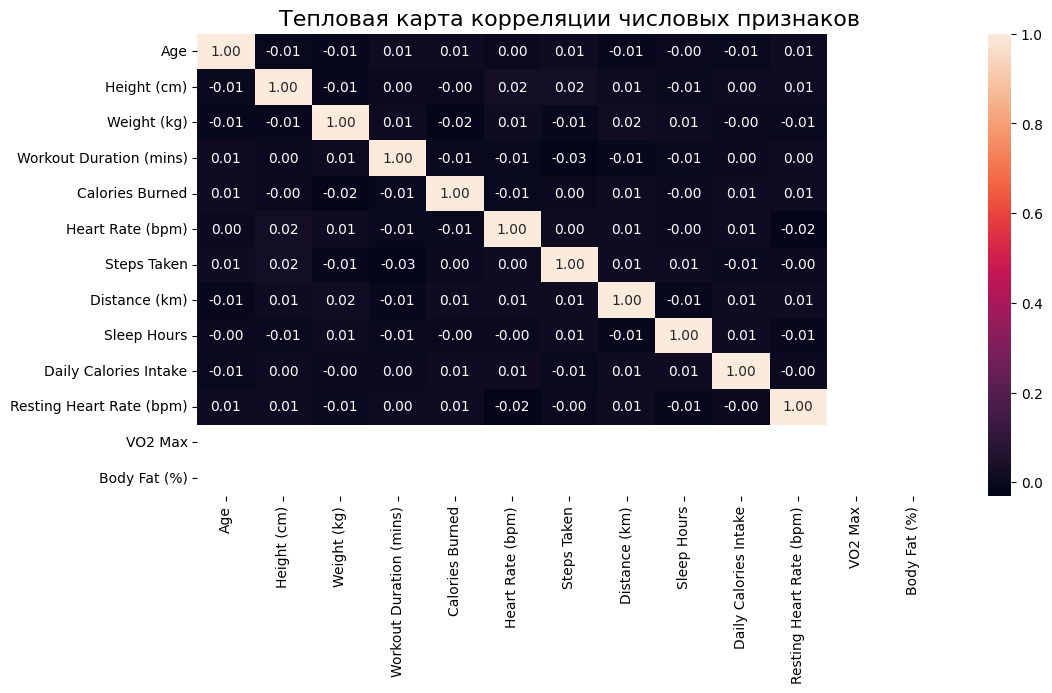

In [102]:
plt.figure(figsize=(12, 6))
numeric_columns = ['Age', 'Height (cm)', 'Weight (kg)', 'Workout Duration (mins)',
                   'Calories Burned', 'Heart Rate (bpm)', 'Steps Taken', 'Distance (km)',
                   'Sleep Hours', 'Daily Calories Intake', 'Resting Heart Rate (bpm)',
                   'VO2 Max', 'Body Fat (%)']
sns.heatmap(df[numeric_columns].corr(), annot=True, fmt='.2f')
plt.title('Тепловая карта корреляции числовых признаков', fontsize=16)


In [103]:
df.drop(['Water Intake (liters)', 'User ID'], axis=1, inplace=True)

In [104]:
df.head()

,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Workout Intensity,Sleep Hours,Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout
0,39,Male,175,99,Cycling,79,384,112,8850,14.44,High,8.2,3195,61,38.4,28.5,Tired,Fatigued
1,36,Other,157,112,Cardio,73,612,168,2821,1.10,High,8.6,2541,73,38.4,28.5,Happy,Energized
2,25,Female,180,66,HIIT,27,540,133,18898,7.28,High,9.8,3362,80,38.4,28.5,Happy,Fatigued
3,56,Male,154,89,Cycling,39,672,118,14102,6.55,Medium,5.8,2071,65,38.4,28.5,Neutral,Neutral
4,53,Other,194,59,Strength,56,410,170,16518,3.17,Medium,7.3,3298,59,38.4,28.5,Stressed,Energized


In [105]:
df = pd.get_dummies(df, columns=['Gender', 'Workout Type', 'Workout Intensity', 'Mood Before Workout', 'Mood After Workout'], drop_first=True)

In [107]:
df.head()

,Age,Height (cm),Weight (kg),Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Sleep Hours,Daily Calories Intake,...,Workout Type_Running,Workout Type_Strength,Workout Type_Yoga,Workout Intensity_Low,Workout Intensity_Medium,Mood Before Workout_Neutral,Mood Before Workout_Stressed,Mood Before Workout_Tired,Mood After Workout_Fatigued,Mood After Workout_Neutral
0,39,175,99,79,384,112,8850,14.44,8.2,3195,...,False,False,False,False,False,False,False,True,True,False
1,36,157,112,73,612,168,2821,1.10,8.6,2541,...,False,False,False,False,False,False,False,False,False,False
2,25,180,66,27,540,133,18898,7.28,9.8,3362,...,False,False,False,False,False,False,False,False,True,False
3,56,154,89,39,672,118,14102,6.55,5.8,2071,...,False,False,False,False,True,True,False,False,False,True
4,53,194,59,56,410,170,16518,3.17,7.3,3298,...,False,True,False,False,True,False,True,False,False,False


In [108]:
X = df.drop('Calories Burned',axis = 1)
y = df['Calories Burned']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [111]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [116]:
xgb_model = XGBRegressor()

In [117]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [118]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
)

In [119]:
grid_search.fit(X_train_sc,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error')

In [120]:
best_model = grid_search.best_estimator_

In [121]:
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [123]:
y_pred = best_model.predict(X_test_sc)

In [125]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

In [126]:
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 66548.65625
R2 Score: -0.0004820823669433594


In [127]:
best_model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)